🎯 Target values: [2 1 0]
✅ All input features are numeric.

✅ Data ready: 9852 training samples, 2464 test samples

🔍 Training: Logistic Regression

🔍 Training: Decision Tree

🔍 Training: Random Forest

📊 Evaluation Report - Logistic Regression
Accuracy: 0.8458
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        31
           1      0.000     0.000     0.000       349
           2      0.846     1.000     0.916      2084

    accuracy                          0.846      2464
   macro avg      0.282     0.333     0.305      2464
weighted avg      0.715     0.846     0.775      2464



/Users/futureinlaw/Development/USIU/1.2/traffic-accident-severity-prediction/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/futureinlaw/Development/USIU/1.2/traffic-accident-severity-prediction/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/futureinlaw/Development/USIU/1.2/traffic-accident-severity-prediction/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set t

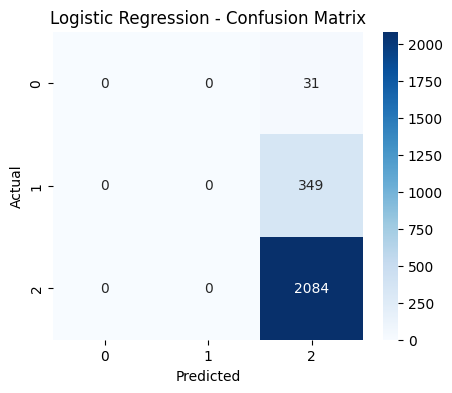


📊 Evaluation Report - Decision Tree
Accuracy: 0.7216
              precision    recall  f1-score   support

           0      0.024     0.032     0.027        31
           1      0.174     0.212     0.191       349
           2      0.853     0.817     0.835      2084

    accuracy                          0.722      2464
   macro avg      0.350     0.354     0.351      2464
weighted avg      0.746     0.722     0.733      2464



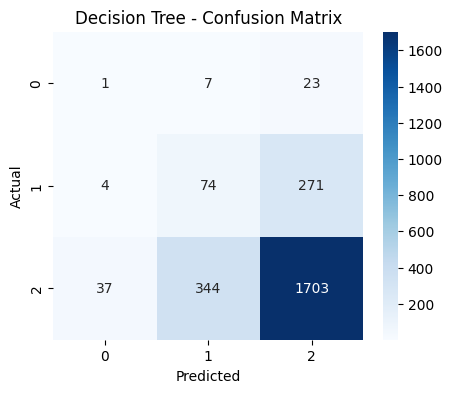


📊 Evaluation Report - Random Forest
Accuracy: 0.8405
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        31
           1      0.269     0.020     0.037       349
           2      0.847     0.990     0.913      2084

    accuracy                          0.841      2464
   macro avg      0.372     0.337     0.317      2464
weighted avg      0.754     0.841     0.778      2464



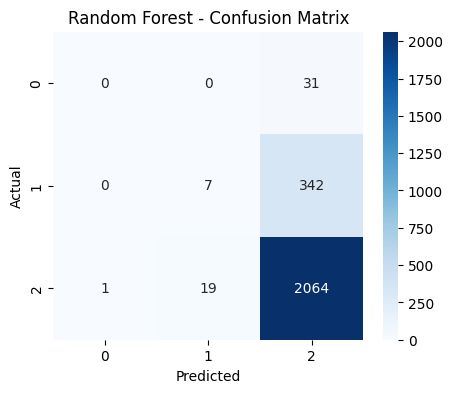

In [4]:
# Week 4 - Model Training

# --- Step 0: Load and prepare data ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load cleaned dataset
df = pd.read_csv('../data/cleaned.csv')

# Confirm target values
print("🎯 Target values:", df['Accident_severity'].unique())

# --- Step 1: One-hot encode categorical columns ---

categorical_cols = [
    'Age_band_of_driver', 'Sex_of_driver', 'Educational_level',
    'Driving_experience', 'Lanes_or_Medians', 'Types_of_Junction',
    'Road_surface_type', 'Light_conditions', 'Weather_conditions',
    'Type_of_collision', 'Vehicle_movement', 'Pedestrian_movement',
    'Cause_of_accident', 'Vehicle_driver_relation'  # ✅ Added this missing column
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# --- Step 2: Split features and target ---
X = df_encoded.drop(columns=['Accident_severity'])
y = df_encoded['Accident_severity']

# Confirm that all features are numeric
non_numeric_cols = X.select_dtypes(include=['object']).columns
if len(non_numeric_cols) > 0:
    raise ValueError(f"❌ Non-numeric columns still present: {list(non_numeric_cols)}")
else:
    print("✅ All input features are numeric.")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Data ready: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples")

# --- Step 3: Train Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression
print("\n🔍 Training: Logistic Regression")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Decision Tree
print("\n🔍 Training: Decision Tree")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# Random Forest
print("\n🔍 Training: Random Forest")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Step 4: Evaluation Function ---
def evaluate_model(name, y_true, y_pred):
    print(f"\n📊 Evaluation Report - {name}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, digits=3))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# --- Step 5: Evaluate All Models ---
evaluate_model("Logistic Regression", y_test, lr_preds)
evaluate_model("Decision Tree", y_test, dt_preds)
evaluate_model("Random Forest", y_test, rf_preds)